# GLiNER Finetuned Model Output analysis on PRWP documents

In [1]:
%%capture
!pip install pymupdf rapidfuzz pdfplumber

In [2]:
import re
def extract_title_abstract(doc):
    """
    Extract full title and abstract from a PyMuPDF document.
    - Title: longest sequence of lines with the largest font size (from page 0)
    - Abstract: block starting with 'Abstract' until 'Introduction' or similar (from page 1)
    """
    import re

    first_page = doc[0]
    blocks = first_page.get_text("dict")["blocks"]

    # Extract all spans with position, size, and text
    spans = []
    for block in blocks:
        for line in block.get("lines", []):
            for span in line["spans"]:
                spans.append({
                    "text": clean_text(span["text"]),
                    "size": span["size"],
                    "y": span["bbox"][1],  # top coordinate
                    "x": span["bbox"][0]
                })

    # Extract title by grouping spans with largest font
    if not spans:
        return {"title": "", "abstract": ""}

    max_font_size = max(span["size"] for span in spans)
    title_spans = [s for s in spans if s["size"] >= max_font_size - 1]
    title_spans.sort(key=lambda s: (s["y"], s["x"]))
    title = " ".join([s["text"] for s in title_spans]).strip()

    # Extract abstract from page 1 (second page)
    abstract = ""
    abstract_started = False
    if len(doc) > 1:
        second_page = doc[1]
        blocks = second_page.get_text("dict")["blocks"]
        for block in blocks:
            block_text = ""
            for line in block.get("lines", []):
                full_line = " ".join(span["text"] for span in line["spans"]).strip()
                if not full_line:
                    continue
                if "abstract" in full_line.lower() and not abstract_started:
                    abstract_started = True
                if abstract_started:
                    if full_line.lower() in ["introduction", "1 introduction"]:
                        break
                    block_text += full_line + " "
            if abstract_started:
                abstract += block_text

    return {
        "title": title,
        "abstract": abstract.strip()
    }


In [3]:
import pymupdf

In [4]:
def get_title_from_doc(document_id):
    try:
        doc = pymupdf.open(document_id)
        #doc = pymupdf.open(f"/kaggle/input/onedrive-prwp/document/{document_id}.pdf")
    except:
        doc = pymupdf.open(f"/kaggle/input/onedrive-prwp/document/{document_id}.pdf")
    metadata = extract_title_abstract(doc)

    return metadata["title"], metadata['abstract']

In [5]:
def clean_text(text):
    # 'Public Disclosure Authorized'
    text = re.sub(r'(Public Disclosure Authorized\s*)+', '', text)
    
    # Remove excessive newlines
    text = re.sub(r'\n+', '\n', text)
    
    # Format into readable paragraphs
    paragraphs = text.split('\n')
    cleaned_paragraphs = [para.strip() for para in paragraphs if para.strip()]
    
    return '\n\n'.join(cleaned_paragraphs)

In [6]:
get_title_from_doc("/kaggle/input/onedrive-prwp/document/document_10000577.pdf")

('Crises, Capital Controls, and Financial Integration',
 'Abstract The Policy Research Working Paper Series disseminates the findings of work in progress to encourage the exchange of ideas about development issues. An objective of the series is to get the findings out quickly, even if the presentations are less than fully polished. The papers carry the names of the authors and should be cited accordingly. The findings, interpretations, and conclusions expressed in this paper are entirely those of the authors. They do not necessarily represent the views of the International Bank for Reconstruction and Development/World Bank and its affiliated organizations, or those of the Executive Directors of the World Bank or the governments they represent. P olicy  R esearch  W orking  P aper  4770 This paper analyzes the effects of capital controls and crises on international financial integration, using data on stocks from emerging economies that trade in domestic and international markets. The c

In [7]:
get_title_from_doc("/kaggle/input/onedrive-prwp/document/document_1000459.pdf")

('Malaysian Capital Controls', '')

In [8]:
get_title_from_doc("/kaggle/input/onedrive-prwp/document/document_10009164.pdf")

('Migration and Education Decisions in a Dynamic General Equilibrium Framework',
 'Abstract The Policy Research Working Paper Series disseminates the findings of work in progress to encourage the exchange of ideas about development issues. An objective of the series is to get the findings out quickly, even if the presentations are less than fully polished. The papers carry the names of the authors and should be cited accordingly. The findings, interpretations, and conclusions expressed in this paper are entirely those of the authors. They do not necessarily represent the views of the International Bank for Reconstruction and Development/World Bank and its affiliated organizations, or those of the Executive Directors of the World Bank or the governments they represent. P olicy  R esearch  W orking  P aper  4775 With growing international skilled labor mobility, education and migration decisions have become increasingly inter-related, and potentially have a large impact on the growth tra

In [9]:
import pandas as pd
import glob

fnames = glob.glob("/kaggle/input/prwp-gliner-outputs/output/*.json")
#fnames_2 = glob.glob("/kaggle/input/iclr-prwp-documents/output/*.json")

In [10]:
#len(fnames), len(fnames_2)

In [11]:
#fnames = fnames + fnames_2

In [12]:
len(fnames)

4798

In [13]:
from tqdm.auto import tqdm

In [14]:
import pandas as pd
import concurrent.futures
from tqdm import tqdm

def read_json_file(fname):
    df = pd.read_json(fname)
    return df if not df.empty else None

res_df = pd.DataFrame()

with concurrent.futures.ThreadPoolExecutor() as executor:
    futures = {executor.submit(read_json_file, fname): fname for fname in fnames}
    for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures), desc="processing dfs"):
        result = future.result()
        if result is not None:
            res_df = pd.concat([res_df, result], axis=0)

processing dfs: 100%|██████████| 4798/4798 [00:19<00:00, 252.24it/s]


In [15]:
res_df.shape

(44294, 5)

In [16]:
res_df.head()

,source,page,text,dataset,relations
0,document_11367559,2,Explaining high transport costs within Malawi ...,"{'start': 524, 'end': 551, 'text': 'Country Ec...","[{'source': 'Country Economic Memorandum', 're..."
1,document_11367559,9,"- 5 - 10. However, the extensive physical conn...","{'start': 270, 'end': 313, 'text': 'Highway De...",[{'source': 'Highway Development and Maintenan...
2,document_11367559,9,"- 5 - 10. However, the extensive physical conn...","{'start': 394, 'end': 399, 'text': 'HDM-4', 'l...","[{'source': 'HDM-4', 'relation': 'acronym', 't..."
3,document_11367559,9,"- 5 - 10. However, the extensive physical conn...","{'start': 536, 'end': 560, 'text': 'spatial an...",[]
4,document_11367559,10,- 6 - Box 1: Linking spatial data on road netw...,"{'start': 229, 'end': 233, 'text': 'HDM4', 'la...","[{'source': 'HDM4', 'relation': 'publisher', '..."


In [17]:
# source_df = pd.DataFrame(res_df['source'].unique(), columns=['source'])

In [18]:
# %%time

# source_df['title_abstract'] = source_df['source'].map(get_title_from_doc)

In [19]:
# source_df.head()

In [20]:
# source_df['title'] = source_df['title_abstract'].apply(lambda x: x[0])

In [21]:
# source_df['abstract'] = source_df['title_abstract'].apply(lambda x: x[1])

In [22]:
# source_df.head()

In [23]:
# %%time

# source_df['title'] = source_df['source'].map(get_title_from_doc)

In [24]:
# source_df.to_csv("document_titles.csv", index=False)

In [25]:
source_df = pd.read_csv("/kaggle/input/onedrive-document-titles/document_titles.csv")

In [26]:
source_df.head()

,source,title_abstract,title,abstract
0,document_15084797,('Unpacking the Causal Chain of Financial Lite...,Unpacking the Causal Chain of Financial Literacy,Abstract The Policy Research Working Paper Ser...
1,document_9840056,"('Hunting for Leopards:', 'Abstract The Policy...",Hunting for Leopards:,Abstract The Policy Research Working Paper Ser...
2,document_11357173,"('Basel Core Principles and Bank Soundness', '...",Basel Core Principles and Bank Soundness,Abstract The Policy Research Working Paper Ser...
3,document_1047468,"('H', '')",H,NaN
4,document_694818,"('17?70', '')",17?70,NaN


In [27]:
res_df = res_df.merge(source_df, on='source', how='left')

In [28]:
res_df.head()

,source,page,text,dataset,relations,title_abstract,title,abstract
0,document_11367559,2,Explaining high transport costs within Malawi ...,"{'start': 524, 'end': 551, 'text': 'Country Ec...","[{'source': 'Country Economic Memorandum', 're...",('Explaining High Transport Costs within Malaw...,Explaining High Transport Costs within Malawi,Abstract The Policy Research Working Paper Ser...
1,document_11367559,9,"- 5 - 10. However, the extensive physical conn...","{'start': 270, 'end': 313, 'text': 'Highway De...",[{'source': 'Highway Development and Maintenan...,('Explaining High Transport Costs within Malaw...,Explaining High Transport Costs within Malawi,Abstract The Policy Research Working Paper Ser...
2,document_11367559,9,"- 5 - 10. However, the extensive physical conn...","{'start': 394, 'end': 399, 'text': 'HDM-4', 'l...","[{'source': 'HDM-4', 'relation': 'acronym', 't...",('Explaining High Transport Costs within Malaw...,Explaining High Transport Costs within Malawi,Abstract The Policy Research Working Paper Ser...
3,document_11367559,9,"- 5 - 10. However, the extensive physical conn...","{'start': 536, 'end': 560, 'text': 'spatial an...",[],('Explaining High Transport Costs within Malaw...,Explaining High Transport Costs within Malawi,Abstract The Policy Research Working Paper Ser...
4,document_11367559,10,- 6 - Box 1: Linking spatial data on road netw...,"{'start': 229, 'end': 233, 'text': 'HDM4', 'la...","[{'source': 'HDM4', 'relation': 'publisher', '...",('Explaining High Transport Costs within Malaw...,Explaining High Transport Costs within Malawi,Abstract The Policy Research Working Paper Ser...


In [29]:
%%capture
# For the embedding model
from sentence_transformers import SentenceTransformer
# This part downloads the embedding model from HuggingFace.
# In case a pop-up will ask for a secret, just cancel/close it. That is not needed for open models.
model = SentenceTransformer("avsolatorio/GIST-small-Embedding-v0", use_auth_token=False)

2025-06-27 03:07:09.083955: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750993629.291150      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750993629.351565      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [30]:
source_df[['title', 'abstract']].to_dict(orient='records')[0]

{'title': 'Unpacking the Causal Chain of Financial Literacy',
 'abstract': 'Abstract The Policy Research Working Paper Series disseminates the findings of work in progress to encourage the exchange of ideas about development issues. An objective of the series is to get the findings out quickly, even if the presentations are less than fully polished. The papers carry the names of the authors and should be cited accordingly. The findings, interpretations, and conclusions expressed in this paper are entirely those of the authors. They do not necessarily represent the views of the International Bank for Reconstruction and Development/World Bank and its affiliated organizations, or those of the Executive Directors of the World Bank or the governments they represent. Policy Research Working Paper 5798 A growing body of literature examines the causal impact of financial literacy on individual, household, and firm level outcomes. This paper unpacks the mechanism of impact by focusing on the fi

In [31]:
def get_content(metadata: dict) -> str:
    """
    Extract title + abstract safely, even if abstract is missing or not text.
    """
    # Clean up title (since it was extracted, might also be non-str)
    title = metadata.get("title", "")
    try:
        title = re.sub(r"\s+", " ", title).strip()
    except Exception:
        title = str(title)

    # Try to clean abstract, else ignore
    abstract = metadata.get("abstract", "")
    try:
        abstract = re.sub(r"\s+", " ", abstract).strip()
        return f"{title}\n\n{abstract}"
    except Exception:
        # fallback to title only
        return title

In [32]:
metadata = source_df[['source', 'title', 'abstract']].to_dict(orient='records')

In [33]:
get_content(metadata[0])

'Unpacking the Causal Chain of Financial Literacy\n\nAbstract The Policy Research Working Paper Series disseminates the findings of work in progress to encourage the exchange of ideas about development issues. An objective of the series is to get the findings out quickly, even if the presentations are less than fully polished. The papers carry the names of the authors and should be cited accordingly. The findings, interpretations, and conclusions expressed in this paper are entirely those of the authors. They do not necessarily represent the views of the International Bank for Reconstruction and Development/World Bank and its affiliated organizations, or those of the Executive Directors of the World Bank or the governments they represent. Policy Research Working Paper 5798 A growing body of literature examines the causal impact of financial literacy on individual, household, and firm level outcomes. This paper unpacks the mechanism of impact by focusing on the first link in the causal 

In [34]:
records = source_df.to_dict(orient="records")
doc_ids  = [r["source"] for r in records]

# build the text blobs
doc_contents = [get_content(r) for r in tqdm(records)]

100%|██████████| 3335/3335 [00:00<00:00, 13237.54it/s]


In [35]:
# 3) Run your encoder
embeddings = model.encode(
    doc_contents,
    batch_size=32,
    show_progress_bar=True
)

Batches:   0%|          | 0/105 [00:00<?, ?it/s]

In [36]:
query = "Which documents are related to Refugees or Displacement?"

q_embedding = model.encode(query)
sim_scores = model.similarity(q_embedding, embeddings)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [37]:
for rank, ix in enumerate(sim_scores.flatten().argsort(descending=True)[:10]):
    ix = ix.cpu().item()
    title = re.sub(r'\s+', ' ', records[ix]["title"])
    print(f"{rank + 1}. {title}")

1. Relative Deprivation and Migration
2. Revised Estimates and Projections of International Migration
3. Impact of Migration on Economic and Social Development
4. A Gendered Assessment of the Brain Drain
5. Experimental Approaches in Migration Studies
6. Diaspora Effects in International Migration
7. International Migration, Remittances, and the Brain Drain
8. Internal Migration in Ghana
9. The Distribution of Foreign
10. Who Migrates Overseas and Is It Worth Their While?


In [38]:
%%capture
!pip install datamapplot

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [39]:
# Dimensionality reduction
import umap

# Clustering
import hdbscan

# Create interactive cluster map
import datamapplot

Interactive DataMapPlot is taken from [Aivin's Notebook](https://colab.research.google.com/drive/1XudvpG8pYrAiGANn_mMNJzDOmlataXQB#scrollTo=A42ubmS_HgI_)

In [40]:
# from https://colab.research.google.com/drive/1XudvpG8pYrAiGANn_mMNJzDOmlataXQB#scrollTo=A42ubmS_HgI_
umap_model = umap.UMAP(
    # The size of local neighborhood (in terms of number of neighboring sample points) used for
    # manifold approximation.
    # Larger values result in more global views of the manifold, while smaller values result in
    # more local data being preserved. In general values should be in the range 2 to 100.
    n_neighbors=50,

    # The dimension of the space to embed into.
    # This defaults to 2 to provide easy visualization, but can reasonably be set to any
    # integer value in the range 2 to 100.
    n_components=2,

    min_dist=0.0,
    negative_sample_rate=50,
    metric='cosine',
    random_state=1029  # For reproducibility - to prevent stochastic behaviour of UMAP.
    # n_jobs=128,
)

umap_model

UMAP(metric='cosine', min_dist=0.0, n_neighbors=50, negative_sample_rate=50, random_state=1029)

In [41]:
%%time
# Fit and transform the high-dimensional embeddings into their corresponding 2-dimensional compressed vectors.
# Takes about 2 mins in Google Colab. :)

u_embeddings = umap_model.fit_transform(embeddings)

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: user 1min 29s, sys: 305 ms, total: 1min 29s
Wall time: 1min 29s


In [42]:
import numpy as np

In [43]:
%%time

hdbscan_model = hdbscan.HDBSCAN(
    # Control the number of topics with this parameter.
    # The minimum size of clusters; single linkage splits that contain fewer points than
    # this will be considered points "falling out" of a cluster rather than a cluster splitting
    # into two new clusters.
    min_cluster_size=50,

    metric='l2',
    cluster_selection_method='leaf',
    prediction_data=True,
)

clusters = hdbscan_model.fit_predict(u_embeddings)
cluster_ids = np.unique(clusters)

print("Number of clusters detected:", len(cluster_ids))

Number of clusters detected: 20
CPU times: user 101 ms, sys: 2.02 ms, total: 103 ms
Wall time: 109 ms


In [44]:
# Here we structure the input for the visualization of the results.
# Presenting the output of the methods we have down so far visually would help us easily highlight the structure of the data.

# This will be what's shown when we later hover over a point in the graph.
hover_text = doc_contents

# We extract some metadata here. We assume the doc_contents were generated as "<title>\n\n<abstract>".
titles = [i.split("\n\n")[0] for i in doc_contents]
abstracts = [i.split("\n\n")[-1] if len(i.split("\n\n")) > 1 else "" for i in doc_contents]
labels = [str(i) for i in clusters]

In [45]:
# Extract the additional information that we will later pass to our interactive visualization of the clusters.

extra_point_data = pd.DataFrame(list(records))
extra_point_data["title"] = titles
extra_point_data["cluster"] = clusters
extra_point_data["abstract"] = abstracts

In [46]:
extra_point_data.head()

,source,title_abstract,title,abstract,cluster
0,document_15084797,('Unpacking the Causal Chain of Financial Lite...,Unpacking the Causal Chain of Financial Literacy,Abstract The Policy Research Working Paper Ser...,14
1,document_9840056,"('Hunting for Leopards:', 'Abstract The Policy...",Hunting for Leopards:,Abstract The Policy Research Working Paper Ser...,18
2,document_11357173,"('Basel Core Principles and Bank Soundness', '...",Basel Core Principles and Bank Soundness,Abstract The Policy Research Working Paper Ser...,14
3,document_1047468,"('H', '')",H,,-1
4,document_694818,"('17?70', '')",17?70,,1


In [47]:
# This function, in case you are able to provide an OPENAI_API_KEY, will
# allow you to use it for generating the cluster labels instead of the open source LLM.
from kaggle_secrets import UserSecretsClient
import os
user_secrets = UserSecretsClient()
os.environ['OPENAI_API_KEY'] = user_secrets.get_secret("OPENAI_API_KEY")
def openai_llm(model: str = "gpt-4o-mini", temperature: float = 0):
    """
    Wraps a function that generates cluster labels using the OpenAI API.

    :param model: The model to use for generating the cluster labels.
    :param temperature: The temperature to use for generating the cluster labels.

    :return: A function that takes in a list of messages and returns a string.
    """
    import openai
    from google.colab import userdata
    client = openai.Client()
    def _func(messages):
        r = client.chat.completions.create(
            messages=messages,
            model=model,
            temperature=temperature,
            seed=1029,
        )

        return r.choices[0].message.content

    return _func

In [48]:
CLUSTER_LABEL_PROMPT = """You are given a list of sample document titles representing a cluster.

Provide the most relevant cluster label that best represent the documents.

Only give the cluster label and nothing else, no explanation."""


def get_cluster_titles(cluster_id, n=50, random_state=1029):
    """
    Get the titles of the documents in a cluster. This is used as the input for the LLM in the cluster labeling task.

    :param cluster_id: The cluster ID.
    :param n: The number of titles to return.
    :param random_state: The random state.

    :return: A list of titles.
    """
    sample = extra_point_data.loc[extra_point_data["cluster"] == cluster_id, "title"]
    titles = sample.sample(min(len(sample), n), random_state=random_state).tolist()

    return titles

In [49]:
%%time
# Select which one model to use for the labeling. Only works if you have the OpenAI key.
import json
llm_generator = openai_llm()

label_code_label = {}

for c in tqdm(cluster_ids):
    l = str(c)
    titles = get_cluster_titles(c, n=100)

    messages = [
        {"role": "system", "content": CLUSTER_LABEL_PROMPT},
        {"role": "user", "content": json.dumps(titles)}
    ]

    # label_code_label[l] = run_llm(messages)
    label_code_label[l] = llm_generator(messages)

100%|██████████| 20/20 [00:13<00:00,  1.44it/s]

CPU times: user 947 ms, sys: 200 ms, total: 1.15 s
Wall time: 15.2 s


In [50]:
label_code_label

{'-1': 'Economic Development and Gender Issues',
 '0': 'Letter U',
 '1': 'Document Identifiers and Codes',
 '2': 'Climate Change and Sustainable Development',
 '3': 'World Bank Policy Research',
 '4': 'World Bank Policy Studies',
 '5': 'World Bank Policy Studies',
 '6': 'WPS Reports',
 '7': 'WPS Document Series',
 '8': 'WPS Reports',
 '9': 'International Migration and Remittances',
 '10': 'Agricultural Economics and Climate Change in Africa',
 '11': 'Infrastructure Development and Policy',
 '12': 'Global Health and Development Issues',
 '13': 'Education and Development in Low-Income Countries',
 '14': 'Financial Services and Economic Development',
 '15': 'Poverty and Inequality',
 '16': 'Labor Market Dynamics and Informality',
 '17': 'International Trade and Development',
 '18': 'Development Economics and Governance'}

In [51]:
# For graphing and formatting
import seaborn as sns
from matplotlib.colors import rgb2hex
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import cm as cmx
# This allows us to assign nice colors to the clusters.
import matplotlib.pyplot as plt
cMap = plt.get_cmap('RdBu_r')
cNorm  = colors.Normalize(vmin=0, vmax=1)
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=cMap)

custom_color_map = dict(
    zip(
        np.unique(labels),
        map(rgb2hex, sns.color_palette("viridis", len(np.unique(labels))))
    )
)
custom_color_map["0"] = "#33333355"

In [52]:
extra_point_data.head()

,source,title_abstract,title,abstract,cluster
0,document_15084797,('Unpacking the Causal Chain of Financial Lite...,Unpacking the Causal Chain of Financial Literacy,Abstract The Policy Research Working Paper Ser...,14
1,document_9840056,"('Hunting for Leopards:', 'Abstract The Policy...",Hunting for Leopards:,Abstract The Policy Research Working Paper Ser...,18
2,document_11357173,"('Basel Core Principles and Bank Soundness', '...",Basel Core Principles and Bank Soundness,Abstract The Policy Research Working Paper Ser...,14
3,document_1047468,"('H', '')",H,,-1
4,document_694818,"('17?70', '')",17?70,,1


In [53]:
records_agg = res_df[['source', 'page', 'dataset', 'relations']].to_dict(orient='records')

In [54]:
import pandas as pd

df = pd.DataFrame(records_agg)

# 1) Wrap the cleaned dataset dict in a list
df['dataset_clean'] = df['dataset'].apply(
    lambda d: [{k:v for k,v in d.items() if k not in ('start','end')}]
)

# 2) Clean each relation as you have it (already a list)
df['relations_clean'] = df['relations'].apply(
    lambda rels: [
        {k:v for k,v in r.items() if k not in ('start','end')}
        for r in rels
    ]
)

# 3) Collapse at the source level
grouped = (
    df
    .groupby('source', as_index=False)
    .agg(
        datasets  = ('dataset_clean',   lambda lists: sum(lists, [])),
        relations = ('relations_clean', lambda lists: sum(lists, []))
    )
)

# 4) (Optional) pack into a single “extracted” column
grouped['extracted'] = grouped.apply(
    lambda row: {
        'datasets':  row['datasets'],
        'relations': row['relations']
    },
    axis=1
)

# 1) make a new column of just the unique (label, text) pairs
grouped['unique_datasets'] = grouped['extracted'].apply(
    lambda ex: list({
        (d['label'], d['text'])
        for d in ex.get('datasets', [])
    })
)

# 2) (optional) if you want to render it in your HTML hover as JSON
grouped['unique_datasets_json'] = grouped['unique_datasets'].apply(
    lambda pairs: json.dumps(pairs, ensure_ascii=False, indent=2)
)

In [55]:
grouped

,source,datasets,relations,extracted,unique_datasets,unique_datasets_json
0,document_10000577,"[{'text': 'local stock market index', 'label':...","[{'source': 'Emerging Market Database', 'relat...",{'datasets': [{'text': 'local stock market ind...,"[(named dataset, local stock market index), (n...","[\n [\n ""named dataset"",\n ""local stock..."
1,document_10000660,"[{'text': 'survey', 'label': 'vague dataset', ...","[{'source': 'Small Business Association', 'rel...","{'datasets': [{'text': 'survey', 'label': 'vag...","[(vague dataset, detailed questionnaire), (nam...","[\n [\n ""vague dataset"",\n ""detailed qu..."
2,document_10002177,"[{'text': 'Human Development Index.', 'label':...","[{'source': 'Human Development Index.', 'relat...",{'datasets': [{'text': 'Human Development Inde...,"[(vague dataset, group and household questionn...","[\n [\n ""vague dataset"",\n ""group and h..."
3,document_10002285,[{'text': 'Country Policy and Institutional As...,[{'source': 'Country Policy and Institutional ...,{'datasets': [{'text': 'Country Policy and Ins...,"[(named dataset, World Development Indicators)...","[\n [\n ""named dataset"",\n ""World Devel..."
4,document_1000581,"[{'text': 'World Health Report', 'label': 'nam...","[{'source': 'World Health Report', 'relation':...","{'datasets': [{'text': 'World Health Report', ...","[(named dataset, World Health Report), (named ...","[\n [\n ""named dataset"",\n ""World Healt..."
...,...,...,...,...,...,...
3330,document_9993138,"[{'text': 'pure transaction database', 'label'...","[{'source': 'pure transaction database', 'rela...",{'datasets': [{'text': 'pure transaction datab...,"[(unnamed dataset, pure transaction database),...","[\n [\n ""unnamed dataset"",\n ""pure tran..."
3331,document_9993216,"[{'text': 'Penn World Tables,', 'label': 'name...","[{'source': 'Penn World Tables,', 'relation': ...","{'datasets': [{'text': 'Penn World Tables,', '...","[(named dataset, Penn World Tables,)]","[\n [\n ""named dataset"",\n ""Penn World ..."
3332,document_9993233,"[{'text': 'Movimento Dos Sem Terra', 'label': ...","[{'source': 'Movimento Dos Sem Terra', 'relati...",{'datasets': [{'text': 'Movimento Dos Sem Terr...,"[(vague dataset, participatory budgeting), (na...","[\n [\n ""vague dataset"",\n ""participato..."
3333,document_9993285,"[{'text': 'Census of Commercial Agriculture', ...",[{'source': 'Census of Commercial Agriculture'...,{'datasets': [{'text': 'Census of Commercial A...,"[(named dataset, Census of Commercial Agricult...","[\n [\n ""named dataset"",\n ""Census of C..."


In [56]:
final = grouped[['source','extracted', 'unique_datasets_json']]

In [57]:
extra_point_data = extra_point_data.merge(final, on='source', how='left')

<InteractiveFigure width=100% height=800>
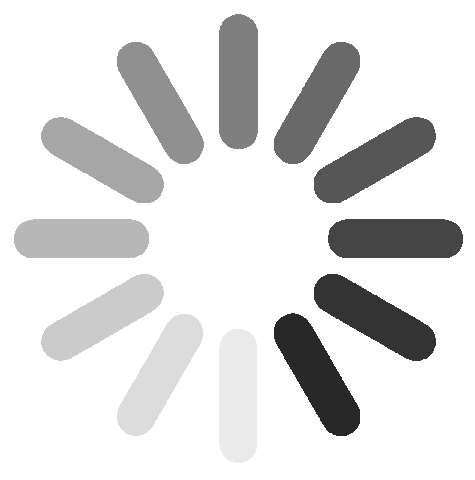

In [58]:
import json

data_map = u_embeddings
hover_text_html_template = """
<h4>{title}</h4>
<pre style="font-size:12px; white-space: pre-wrap;">{unique_datasets_json}</pre>
"""

# 3) Re-call datamapplot with the new column
plot = datamapplot.create_interactive_plot(
    data_map,
    list(map(label_code_label.get, labels)),
    hover_text=True,
    hover_text_html_template=hover_text_html_template,

    title="PRWP OneDrive Dataset Mentions",
    sub_title="A data map of extracted datasets.",

    darkmode=True,
    initial_zoom_fraction=0.8,

    label_color_map={label_code_label[k]: custom_color_map[k] for k in custom_color_map},

    cluster_boundary_polygons=True,
    cluster_boundary_line_width=4,

    # now pass the JSON string, *not* the raw dict
    extra_point_data=extra_point_data[["source", "title", "unique_datasets_json"]],

    # on_click="window.open(`{source}`)",
    enable_search=True,
    height=800,
)

plot.save("gist-small-prwp.html")
plot


# Other Visualizations

In [59]:
def clean_label(s):
    return s.strip().rstrip('.,;')  # remove trailing .,; and whitespace

In [60]:
records = res_df.to_dict(orient='records')

In [61]:
import pandas as pd

flat = pd.json_normalize(
    records,
    record_path='relations',
    meta=[
        'source',                # <-- document ID
        ['dataset','start'],
        ['dataset','end'],
        ['dataset','text'],
        ['dataset','label'],
        ['dataset','score'],
    ],
    record_prefix='rel_'        # prefixes all relation fields (‘rel_source’, ‘rel_start’, etc.)
)

flat = flat.rename(columns={
    'source':         'doc_source',   # your document‐level source
    # dataset (meta) fields
    'dataset.start': 'ds_start',
    'dataset.end':   'ds_end',
    'dataset.text':  'dataset',
    'dataset.label': 'ds_label',
    'dataset.score': 'ds_score',
})

print(flat.columns)

Index(['rel_source', 'rel_relation', 'rel_target', 'rel_score', 'rel_start',
       'rel_end', 'doc_source', 'ds_start', 'ds_end', 'dataset', 'ds_label',
       'ds_score'],
      dtype='object')


In [62]:
flat['dataset'] = flat['dataset'].map(clean_label)

In [63]:
flat['dataset'].nunique() #number of unique datasets

14642

In [64]:
flat = (
    flat
      .sort_values('rel_score', ascending=False)
      .drop_duplicates(subset=['doc_source','dataset','rel_relation'])
      .reset_index(drop=True)
)

In [65]:
flat.loc[flat['ds_label'] == 'vague dataset']['dataset'].value_counts(dropna=False)[:20]

dataset
survey data              389
survey                   386
panel data               291
household surveys        289
surveys                  261
household survey data    210
data set                 182
household survey         155
empirical studies        107
baseline survey           97
firm-level data           79
cross-sectional data      72
empirical literature      70
data sets                 61
household data            59
panel data set            49
case studies              47
quarterly data            47
Survey data               45
database                  44
Name: count, dtype: int64

In [66]:
flat.loc[flat['ds_label'] == 'unnamed dataset']['dataset'].value_counts(dropna=False)[:20]

dataset
household survey                                  66
unique dataset                                    34
panel dataset                                     30
data set                                          24
new dataset                                       23
survey                                            23
new data set                                      21
panel data set                                    21
New Data Set                                      20
database                                          17
unique data set                                   16
unique survey                                     16
longitudinal study                                14
novel dataset                                     14
new database                                      14
follow-up survey                                  13
World Bank study                                  12
comprehensive dataset                             12
baseline survey                       

In [67]:
flat.loc[flat['ds_label'] == 'named dataset']['dataset'].value_counts(dropna=False)[:20]

dataset
Policy Research Working Papers          839
World Development Indicators            538
DHS                                     357
Demographic and Health Surveys          304
household survey                        264
Demographic and Health Survey           255
Enterprise Surveys                      245
census                                  242
World Development Report                237
Census                                  216
LSMS                                    214
AICD                                    182
household surveys                       157
WDI                                     155
International Country Risk Guide        148
Policy Research Working Paper Series    136
PISA                                    131
BEEPS                                   130
CPI                                     129
Household Budget Survey                 129
Name: count, dtype: int64

In [68]:
flat['dataset'].value_counts(dropna=False)[:20]

dataset
Policy Research Working Papers    839
World Development Indicators      538
survey                            491
household survey                  485
household surveys                 453
survey data                       392
DHS                               357
Demographic and Health Surveys    304
panel data                        294
surveys                           287
Demographic and Health Survey     255
Enterprise Surveys                245
census                            242
World Development Report          237
Census                            216
household survey data             215
LSMS                              214
data set                          206
AICD                              182
WDI                               155
Name: count, dtype: int64

In [69]:
flat.columns

Index(['rel_source', 'rel_relation', 'rel_target', 'rel_score', 'rel_start',
       'rel_end', 'doc_source', 'ds_start', 'ds_end', 'dataset', 'ds_label',
       'ds_score'],
      dtype='object')

In [70]:
# make sure each group’s highest‐score row comes first
flat = flat.sort_values(['doc_source', 'rel_source', 'rel_score'], ascending=False)

In [71]:
flat

,rel_source,rel_relation,rel_target,rel_score,rel_start,rel_end,doc_source,ds_start,ds_end,dataset,ds_label,ds_score
48137,rich dataset,reference year,1997 / 98,0.534931,168,177,document_9993318,217,229,rich dataset,vague dataset,0.723983
56115,rich dataset,data source,rich dataset,0.512077,217,229,document_9993318,217,229,rich dataset,vague dataset,0.723983
60303,rich dataset,data geography,Indonesia,0.500137,97,106,document_9993318,217,229,rich dataset,vague dataset,0.723983
27111,political data,data type,political data,0.610438,232,246,document_9993318,232,246,political data,vague dataset,0.818317
45556,political data,reference year,2005,0.542729,158,162,document_9993318,232,246,political data,vague dataset,0.818317
...,...,...,...,...,...,...,...,...,...,...,...,...
18817,Grameen,author,Paxton,0.656000,842,848,document_10002177,919,926,Grameen,named dataset,0.69374
59399,Small Business Association,reference year,1953,0.502684,80,84,document_10000660,17,43,Small Business Association,named dataset,0.614392
6361,Emerging Market Database,publication year,2004,0.788585,926,930,document_10000577,827,851,Emerging Market Database,named dataset,0.833492
36147,Emerging Market Database,publisher,Bloomberg,0.573527,748,757,document_10000577,827,851,Emerging Market Database,named dataset,0.833492


In [72]:
meta = (
    flat
      .pivot_table(
          index=['dataset','ds_label','ds_score','ds_start','ds_end'],
          columns='rel_relation',
          values='rel_target',
          aggfunc='first'        # pick the first target among duplicates
      )
      .reset_index()
)

# drop the “rel_relation” name on columns
meta.columns.name = None

In [73]:
meta.shape

(31929, 16)

In [74]:
meta.publisher.value_counts(dropna=False)

publisher
NaN                                                             27894
World Bank                                                       1190
OECD                                                              147
IMF                                                               143
FAO                                                                52
                                                                ...  
Center for International Financial Analysis and Research Inc        1
Marie Stopes International                                          1
UNECA                                                               1
UNEP                                                                1
African Telecommunications Research Project                         1
Name: count, Length: 1132, dtype: int64

In [75]:
meta.dataset.value_counts(dropna=False)

dataset
Policy Research Working Papers                                381
survey                                                        337
household surveys                                             274
survey data                                                   259
household survey                                              256
                                                             ... 
Revenue Equalization Reserve Fund                               1
Review of Maritime Transport                                    1
Revised ECD Checklist                                           1
Danang University of Economics and Business Administration      1
Restitution Act                                                 1
Name: count, Length: 14642, dtype: int64

In [76]:
import pandas as pd
from rapidfuzz import process, fuzz
import re
from dateutil.parser import parse

# helper functions
def make_canon_map(strings, score_cutoff=80):
    clusters = {}
    for s in strings:
        match = process.extractOne(
            s, clusters.keys(),
            scorer=fuzz.token_sort_ratio,
            score_cutoff=score_cutoff
        )
        if match:
            clusters[match[0]].append(s)
        else:
            clusters[s] = [s]
    # reverse mapping: each original to its cluster’s representative
    canon_map = { member: canon for canon, members in clusters.items() for member in members }
    return canon_map, clusters

def standardize_year_range(s):
    if pd.isna(s):
        return None
    s = str(s)
    yrs = [int(m.group(1)) for m in re.finditer(r'\b((?:19|20)\d{2})\b', s)]
    if len(yrs) == 1:
        return str(yrs[0])
    if len(yrs) >= 2:
        y1, y2 = sorted(yrs[:2])
        return f"{y1}-{y2}"
    try:
        return str(parse(s, fuzzy=True).year)
    except ValueError:
        return None

# Create the year_range column
meta['year_range'] = meta['publication year'].apply(standardize_year_range)

# Build all the maps & clusters
pub_map,  pub_clusters  = make_canon_map(meta['publisher'].dropna().unique(),      score_cutoff=80)
geo_map,  geo_clusters  = make_canon_map(meta['data geography'].dropna().unique(),  score_cutoff=80)
abbr_map, abbr_clusters = make_canon_map(meta['acronym'].dropna().unique(),         score_cutoff=80)
year_map, year_clusters = make_canon_map(meta['year_range'].dropna().unique(),      score_cutoff=100)
desc_map, desc_clusters = make_canon_map(
    meta['data description'].dropna().unique().tolist(),
    score_cutoff=80
)

# Apply the maps back onto meta
meta['publisher_canon']    = meta['publisher'].map(pub_map)
meta['geography_canon']    = meta['data geography'].map(geo_map)
meta['abbreviation_canon'] = meta['acronym'].map(abbr_map)
meta['year_canon']         = meta['year_range'].map(year_map)
meta['description_canon']  = meta['data description'].map(desc_map)

In [77]:
# get the full frequency of each raw string
freq = meta['dataset'].value_counts().to_dict()

# build raw clusters
raw_map, raw_clusters = make_canon_map(
    meta['dataset'].dropna().unique(),
    score_cutoff=80
)

# for each cluster, pick the member with highest freq as representative
freq_clusters = {}
for _, members in raw_clusters.items():
    # If a member never appeared in freq, default to 0
    rep = max(members, key=lambda m: freq.get(m, 0))
    freq_clusters[rep] = members

# reverse-map every string
freq_map = {
    member: rep
    for rep, members in freq_clusters.items()
    for member in members
}

meta['ds_canon'] = meta['dataset'].map(freq_map)

In [78]:
meta['ds_canon'].value_counts(dropna=False)[:20]

ds_canon
survey                                 534
Policy Research Working Papers         386
household surveys                      297
Demographic and Health Surveys         285
household survey                       273
census                                 272
survey data                            268
World Development Indicators           256
DHS                                    240
panel data                             235
Enterprise Surveys                     177
household survey data                  144
LSMS                                   136
data set                               135
World Development Report               114
AICD                                   107
firm-level data                         94
IFLS                                    91
PISA                                    89
Living Standards Measurement Survey     87
Name: count, dtype: int64

In [79]:
meta['publisher_canon'].value_counts(dropna=False)[:20]

publisher_canon
NaN                           27894
World Bank                     1237
OECD                            154
IMF                             144
FAO                              52
WHO                              47
Transparency International       39
AICD                             39
Bank                             31
ILO                              30
Heritage Foundation              29
Freedom House                    29
UNDP                             28
UN                               27
EBRD                             27
United Nations                   26
IBGE                             23
INEGI                            22
World Economic Forum             20
Bloomberg                        20
Name: count, dtype: int64

In [80]:
meta.head()

,dataset,ds_label,ds_score,ds_start,ds_end,acronym,author,data description,data geography,data source,...,reference population,reference year,version,year_range,publisher_canon,geography_canon,abbreviation_canon,year_canon,description_canon,ds_canon
0,1 % Sample Population Surveys,named dataset,0.635095,788,817,NaN,NaN,NaN,NaN,NaN,...,Chinese population,NaN,NaN,1995,NaN,NaN,NaN,1995,NaN,1 % Sample Population Surveys
1,10-Industry Database,named dataset,0.909155,515,535,NaN,NaN,NaN,NaN,NaN,...,NaN,1947,NaN,None,Groningen Growth and Development Centre,NaN,NaN,NaN,NaN,10-Industry Database
2,10-K reports,vague dataset,0.641738,66,78,NaN,NaN,NaN,U. S.,NaN,...,NaN,NaN,NaN,None,NaN,U. S.,NaN,NaN,NaN,10-K reports
3,10-year panel dataset on total factoring turnover,unnamed dataset,0.650797,491,540,NaN,NaN,NaN,NaN,NaN,...,NaN,1993,NaN,None,Factor Chain International,NaN,NaN,NaN,NaN,10-year panel dataset on total factoring turnover
4,100 Village Survey,named dataset,0.604263,174,192,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Mini Susenas,None,NaN,NaN,NaN,NaN,NaN,100 Village Survey


In [81]:
meta.shape

(31929, 23)

In [82]:
import plotly.express as px

# Deduplicate 
reagg = (
    meta
      .sort_values('ds_score', ascending=False)   # keep the highest‐scoring mention
      .drop_duplicates(
         subset=[
           'publisher_canon',
           'geography_canon',
           'year_canon',
           'ds_canon',
           'description_canon'
         ]
      )
      .reset_index(drop=True)
)

# 3) Compute the size (count) and average score for each unique combination
counts_all = (
    reagg
    .groupby([
        'publisher_canon',
        'geography_canon',
        'year_canon',
        'ds_canon',
        'description_canon',
    ], dropna=False)
    .agg(
        size      = ('ds_score','count'),
        avg_score = ('ds_score','mean')
    )
    .reset_index()
)

In [83]:
counts_all['publisher_canon'].value_counts()[:30]

publisher_canon
World Bank                      902
OECD                            138
IMF                              99
FAO                              48
WHO                              46
Transparency International       30
AICD                             30
Bank                             28
Freedom House                    28
ILO                              27
EBRD                             26
UN                               25
United Nations                   24
UNDP                             24
Heritage Foundation              22
IBGE                             21
Bloomberg                        20
INEGI                            19
Eurostat                         17
IPCC                             17
Central Bureau of Statistics     17
PNAD                             16
IFC                              16
IPEA                             16
UNESCO                           15
World Economic Forum             15
WDI                              15
UNCTAD      

In [84]:
# from plotly.offline import init_notebook_mode, iplot
# init_notebook_mode(connected=True)

In [85]:
counts_full = counts_all.dropna(
    subset=[
      'publisher_canon',
      'geography_canon',
      'year_canon',
      'ds_canon'
    ],
    how='any'
)

fig = px.treemap(
    counts_full,
    path=[
        'publisher_canon',
        'geography_canon',
        'year_canon',
        'ds_canon',
        'description_canon'
    ],
    values='size',
    color='avg_score',
    color_continuous_scale='Viridis',
    title='Drill‐down: Publisher → Geography → Year → Dataset → Description'
)
fig.show(renderer='iframe')

# Top Datasets by Geography

In [86]:
import textwrap
import plotly.graph_objects as go

def plot_top_dropdown(
    df,
    group_col: str,
    item_col: str,
    top_n: int = 10,
    menu_x: float = 0.99,
    menu_y: float = 0.99,
    margin: dict = None,
    wrap_width: int = 20,
):
    """
    Creates an interactive horizontal‐bar chart with a dropdown to switch groups.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns `group_col` and `item_col`.
    group_col : str
        Column to group by (e.g. 'year_canon').
    item_col : str
        Column of items to count (e.g. 'ds_canon').
    top_n : int
        Number of top items per group.
    menu_x, menu_y : float
        Position of the dropdown (0−1 coordinates).
    margin : dict or None
        Plot margins; defaults to {'l':300,'r':50,'t':50,'b':50}.
    wrap_width : int
        Max chars before wrapping dropdown labels.
    """
    if margin is None:
        margin = dict(l=300, r=50, t=50, b=50)

    def wrap_label(label):
        return "<br>".join(textwrap.wrap(str(label), wrap_width))

    # count occurrences
    counts = (
        df
        .groupby([group_col, item_col])
        .size()
        .reset_index(name="count")
    )

    # sort groups by total
    group_totals = counts.groupby(group_col)["count"].sum()
    groups_sorted = group_totals.sort_values(ascending=False).index.tolist()

    # create one trace per group
    traces = []
    for grp in groups_sorted:
        subset = (
            counts[counts[group_col] == grp]
            .nlargest(top_n, "count")
            .sort_values("count", ascending=True)
        )
        traces.append(go.Bar(
            x=subset["count"],
            y=subset[item_col],
            orientation="h",
            name=str(grp),
            visible=(grp == groups_sorted[0])
        ))

    # build dropdown buttons
    buttons = []
    for i, grp in enumerate(groups_sorted):
        visible = [j == i for j in range(len(groups_sorted))]
        buttons.append(dict(
            label=wrap_label(grp),
            method="update",
            args=[
                {"visible": visible},
                {
                    "title": f"Top Datasets per {group_col.replace('_canon','')}",
                    "margin": margin
                }
            ]
        ))

    # assemble figure
    fig = go.Figure(data=traces)
    fig.update_layout(
        updatemenus=[dict(
            active=0,
            buttons=buttons,
            x=menu_x, xanchor="right",
            y=menu_y, yanchor="top",
            direction="down",
        )],
        title=f"Top Datasets per {group_col.replace('_canon','')}",
        xaxis_title="Count",
        yaxis_title=item_col.replace("_", " ").title(),
        showlegend=False,
        margin=margin
    )
    fig.show(renderer='iframe')

In [87]:
# Top 10 datasets by year
plot_top_dropdown(reagg, "geography_canon", "ds_canon")

# Top Datasets by Publisher

In [88]:
plot_top_dropdown(reagg, "publisher_canon", "ds_canon")

# Top Datasets by Year

In [89]:
plot_top_dropdown(reagg, "year_canon", "ds_canon")